## Análisis Econométrico del Modelo CAPM y Fama-French: Oil-Dri Corporation of America (ODC)

**Autor:** Guillermo Calvo Gil  
**Tutor:** Ricardo Queralt Sánchez de las Matas  
**Institución:** CUNEF Universidad — Grado en Economía con Minor en International Finance & Banking 
**Fecha:** 2026  

---

Este notebook recoge el análisis econométrico completo desarrollado en el Trabajo de Fin de Grado: Análisis de datos financieros de Oil-Dri Corporation of America (ODC).
El flujo de trabajo se estructura en ocho secciones: 
1 - Importación de librerías
2 - Obtención y consolidación de datos
3 - Análisis exploratorio
4 - Estimación del modelo CAPM inicial
5 - Diagnóstico de residuos
6 - Corrección mediante variables de intervención y estimación robusta Newey-West
7 - Contraste de estabilidad paramétrica
8 - Modelo de tres factores de Fama y French.

## 1. Importación de Librerías y Configuración Inicial

Se cargan todas las dependencias necesarias para el procesamiento de datos, el análisis econométrico y la visualización. Se configura el estilo gráfico y se suprimen los avisos de deprecación para garantizar una ejecución limpia y reproducible.

In [1]:
# 1. Importación de librerías
#!pip install yfinance

import pandas as pd
import numpy as np
import warnings
import yfinance as yf

# Visualización
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Modelado econométrico
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_white, het_breuschpagan, acorr_ljungbox
import scipy.stats as stats
from scipy.stats import norm, gaussian_kde

warnings.filterwarnings("ignore")
plt.rc('figure', figsize=(10, 6), dpi=150)
sns.set_theme(style="whitegrid", palette="muted")

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## 2. Obtención, Limpieza y Consolidación de Datos

Se define un horizonte temporal de diez años (enero 2015 – diciembre 2024) que captura distintos ciclos económicos, lo que permite una estimación estable de los parámetros del modelo. Los datos de cotización se obtienen directamente de Yahoo Finance; los factores de riesgo (Market Premium, SMB, HML) y la tasa libre de riesgo proceden de la base de datos pública de Kenneth French (Dartmouth College), ya integrados en el archivo `returns.csv`.

In [2]:
# 2. Carga y preprocesamiento de datos

start_date = '2014-12-31'
end_date   = '2025-12-31'

# Series de precios (Yahoo Finance)
precio = yf.download('ODC',  start=start_date, end=end_date, interval='1mo', auto_adjust=False)
indice = yf.download('^RUT', start=start_date, end=end_date, interval='1mo', auto_adjust=False)

# Conjuntos de datos

df = pd.read_csv('datos_ODC_tfg.csv', index_col=0, parse_dates=True)
display(df)

# DataFrame principal de estimación (primas de riesgo + factores Fama-French)
returns = pd.read_csv('returns.csv', index_col=0, parse_dates=True)
returns = returns.dropna()
display(returns)

print(f"Período de análisis: {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"Observaciones disponibles para estimación: {len(returns)}")
print(f"Columnas: {returns.columns.tolist()}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,ODC,R2000,Rentabilidad_ODC,Rentabilidad_R2000
Date,,,,
2015-01-01,11.495288,1165.390015,NaN,NaN
2015-02-01,11.401438,1233.369995,-0.008164,0.056694
2015-03-01,12.712557,1252.770020,0.114996,0.015607
2015-04-01,12.398990,1220.130005,-0.024666,-0.026400
2015-05-01,11.741642,1246.530029,-0.053016,0.021406
...,...,...,...,...
2025-08-01,58.811035,2366.419922,0.052837,0.067639
2025-09-01,60.647255,2436.479980,0.031222,0.029176
2025-10-01,55.033604,2479.379883,-0.092562,0.017454


,ODC,R2000,Rentabilidad_ODC,Rentabilidad_R2000,Mkt-RF,SMB,HML,RF,Market Premium,ODC Premium
Date,,,,,,,,,,
2015-02-01,11.401438,1233.369995,-0.008164,0.056694,0.0613,0.0061,-0.0179,0.0000,0.056694,-0.008164
2015-03-01,12.712557,1252.770020,0.114996,0.015607,-0.0111,0.0305,-0.0038,0.0000,0.015607,0.114996
2015-04-01,12.398990,1220.130005,-0.024666,-0.026400,0.0059,-0.0299,0.0180,0.0000,-0.026400,-0.024666
2015-05-01,11.741642,1246.530029,-0.053016,0.021406,0.0137,0.0095,-0.0111,0.0000,0.021406,-0.053016
2015-06-01,11.550999,1253.949951,-0.016237,0.005935,-0.0152,0.0294,-0.0082,0.0000,0.005935,-0.016237
...,...,...,...,...,...,...,...,...,...,...
2025-08-01,58.811035,2366.419922,0.052837,0.067639,0.0184,0.0387,0.0442,0.0038,0.063839,0.049037
2025-09-01,60.647255,2436.479980,0.031222,0.029176,0.0339,-0.0185,-0.0105,0.0033,0.025876,0.027922
2025-10-01,55.033604,2479.379883,-0.092562,0.017454,0.0196,-0.0055,-0.0310,0.0037,0.013754,-0.096262


Período de análisis: 2015-02-01 → 2025-12-01
Observaciones disponibles para estimación: 131
Columnas: ['ODC', 'R2000', 'Rentabilidad_ODC', 'Rentabilidad_R2000', 'Mkt-RF', 'SMB', 'HML', 'RF', 'Market Premium', 'ODC Premium']


## 3. Análisis Exploratorio de Datos

Se analiza el comportamiento individual de ambas series temporales y su relación bivariante. Los gráficos de rentabilidad mensual permiten identificar visualmente episodios de volatilidad elevada, valores atípicos y la estacionariedad de las series en torno a su media. El gráfico de dispersión ofrece una primera estimación visual del coeficiente beta del activo.

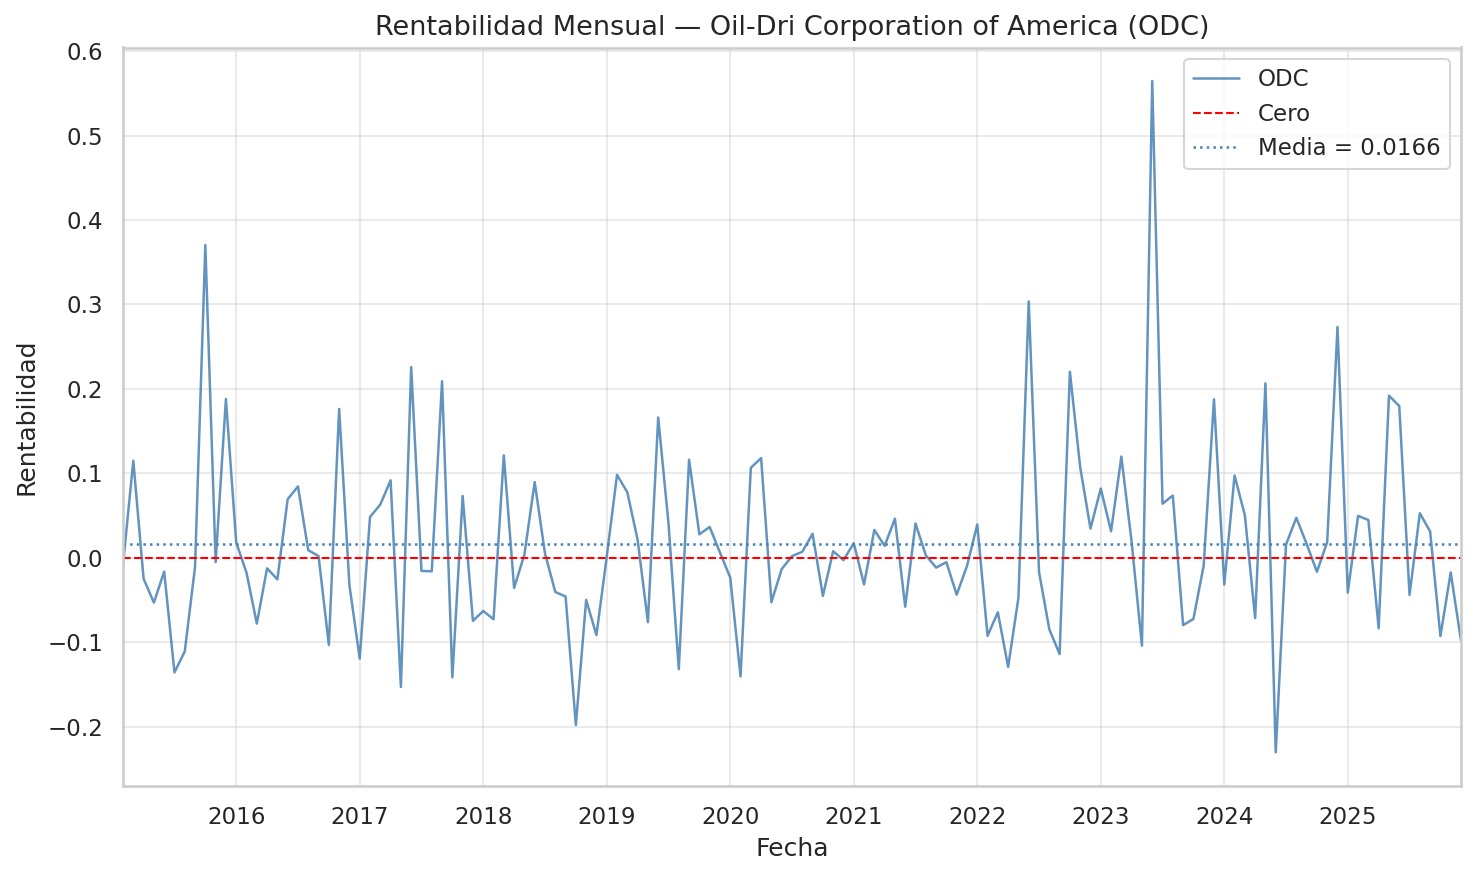

In [3]:
# 3.1 Rentabilidad mensual de ODC

if isinstance(precio.columns, pd.MultiIndex):
    adj_close = precio['Adj Close']['ODC']
else:
    adj_close = precio['Adj Close']

rent_odc = adj_close.pct_change().dropna()
mean_odc = rent_odc.mean()

fig, ax = plt.subplots()
rent_odc.plot(ax=ax, color='steelblue', linewidth=1.2, alpha=0.85)
ax.axhline(0,        color='red',      linewidth=1,   linestyle='--', label='Cero')
ax.axhline(mean_odc, color='steelblue', linewidth=1.2, linestyle=':',
           label=f'Media = {mean_odc:.4f}')
ax.set_title('Rentabilidad Mensual — Oil-Dri Corporation of America (ODC)', fontsize=13)
ax.set_xlabel('Fecha'); ax.set_ylabel('Rentabilidad')
ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('Rentabilidad_ODC.png', dpi=150)
plt.show()

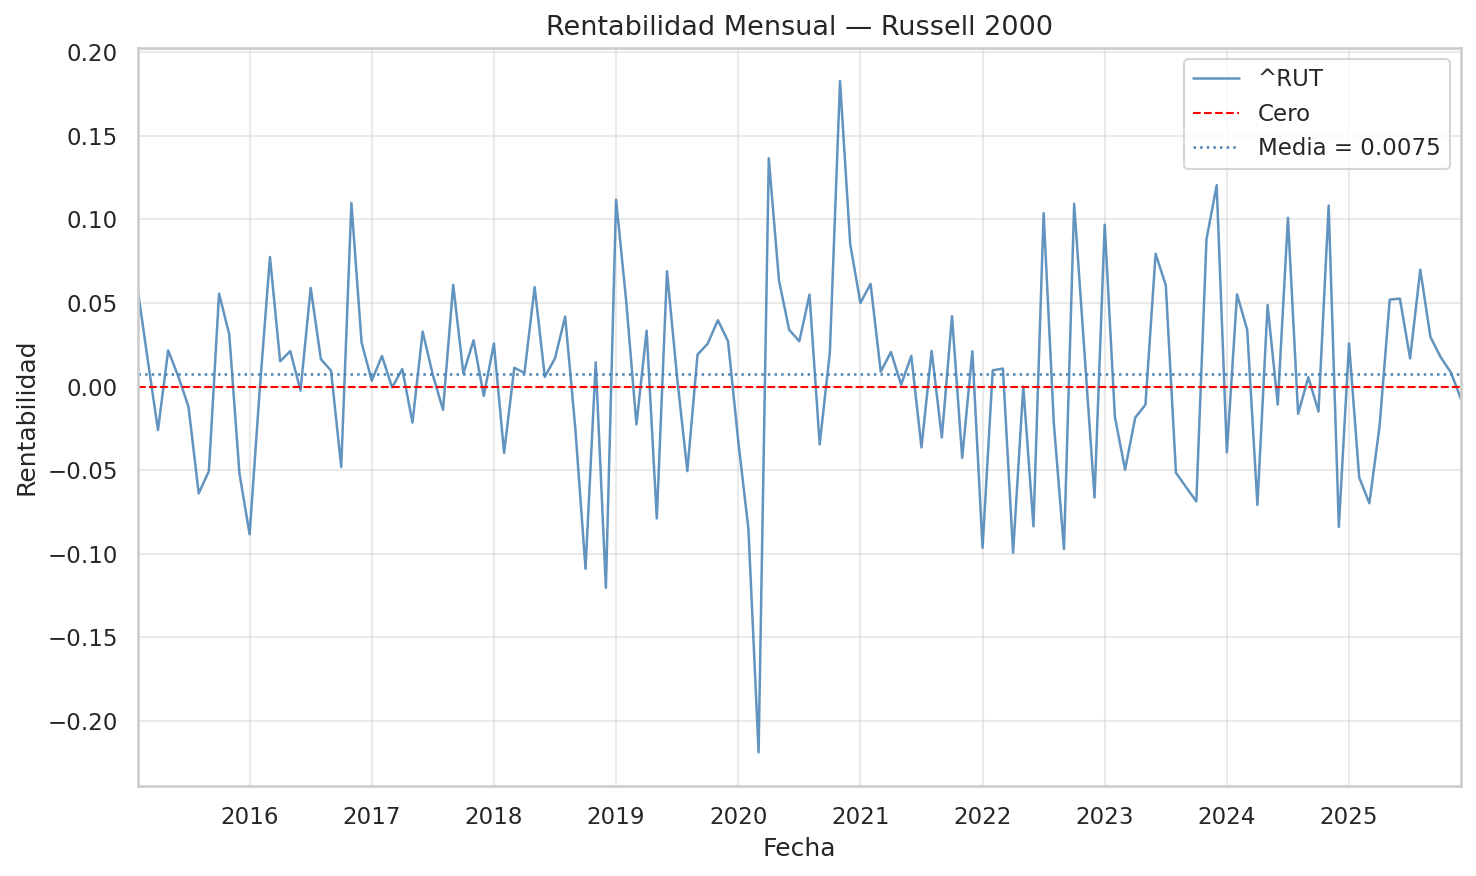

In [4]:
# 3.2 Rentabilidad mensual del índice Russell 2000

if isinstance(indice.columns, pd.MultiIndex):
    adj_close_r2000 = indice['Adj Close']['^RUT']
else:
    adj_close_r2000 = indice['Adj Close']

rent_r2000 = adj_close_r2000.pct_change().dropna()
mean_r2000 = rent_r2000.mean()

fig, ax = plt.subplots()
rent_r2000.plot(ax=ax, color='steelblue', linewidth=1.2, alpha=0.85)
ax.axhline(0,          color='red',      linewidth=1,   linestyle='--', label='Cero')
ax.axhline(mean_r2000, color='steelblue', linewidth=1.2, linestyle=':',
           label=f'Media = {mean_r2000:.4f}')
ax.set_title('Rentabilidad Mensual — Russell 2000', fontsize=13)
ax.set_xlabel('Fecha'); ax.set_ylabel('Rentabilidad')
ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('Rentabilidad_R2000.png', dpi=150)
plt.show()

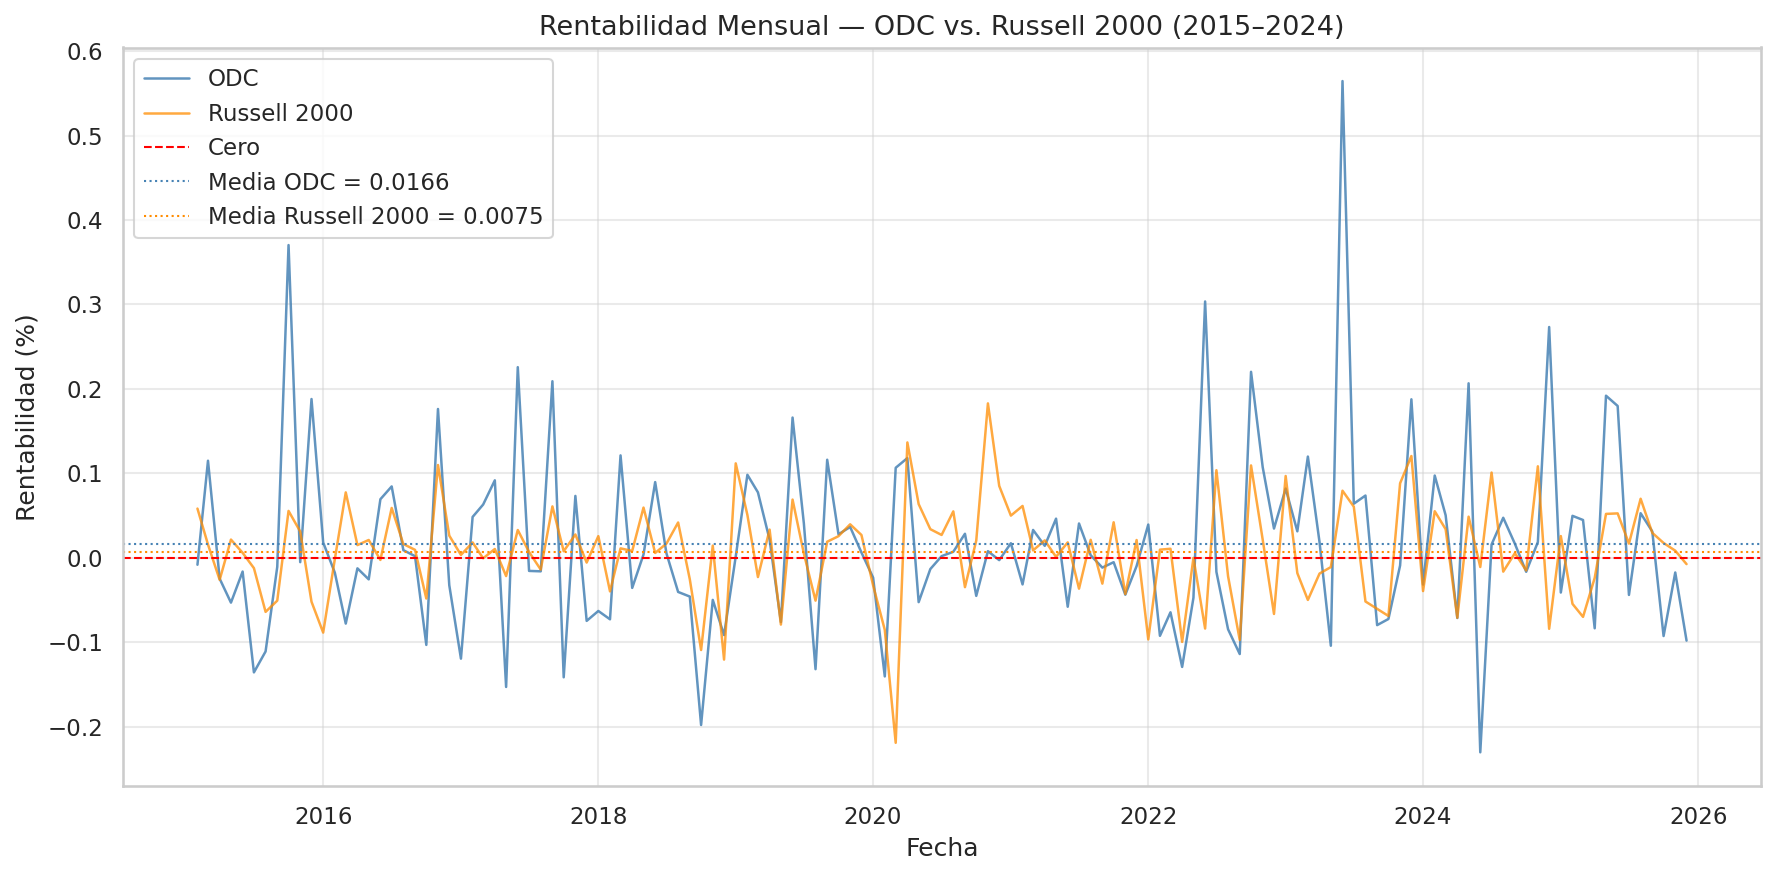

In [5]:
# Gráfico comparativo: Rentabilidad mensual ODC vs. Russell 2000

# ODC 
if isinstance(precio.columns, pd.MultiIndex):
    adj_close_odc = precio['Adj Close']['ODC']
else:
    adj_close_odc = precio['Adj Close']

rent_odc = adj_close_odc.pct_change().dropna()
mean_odc = rent_odc.mean()

#  Russell 2000 
if isinstance(indice.columns, pd.MultiIndex):
    adj_close_r2000 = indice['Adj Close']['^RUT']
else:
    adj_close_r2000 = indice['Adj Close']

rent_r2000 = adj_close_r2000.pct_change().dropna()
mean_r2000 = rent_r2000.mean()

# Gráfico fusionado 
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(rent_odc, color='steelblue', linewidth=1.2, alpha=0.85, label='ODC')
ax.plot(rent_r2000, color='darkorange', linewidth=1.2, alpha=0.75, label='Russell 2000')

ax.axhline(0, color='red', linewidth=1, linestyle='--', label='Cero')
ax.axhline(mean_odc, color='steelblue', linewidth=1, linestyle=':',
           label=f'Media ODC = {mean_odc:.4f}')
ax.axhline(mean_r2000, color='darkorange', linewidth=1, linestyle=':',
           label=f'Media Russell 2000 = {mean_r2000:.4f}')

ax.set_title('Rentabilidad Mensual — ODC vs. Russell 2000 (2015–2024)', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Rentabilidad (%)')
ax.grid(alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig('Rentabilidad_ODC_vs_R2000.png', dpi=150)
plt.show()

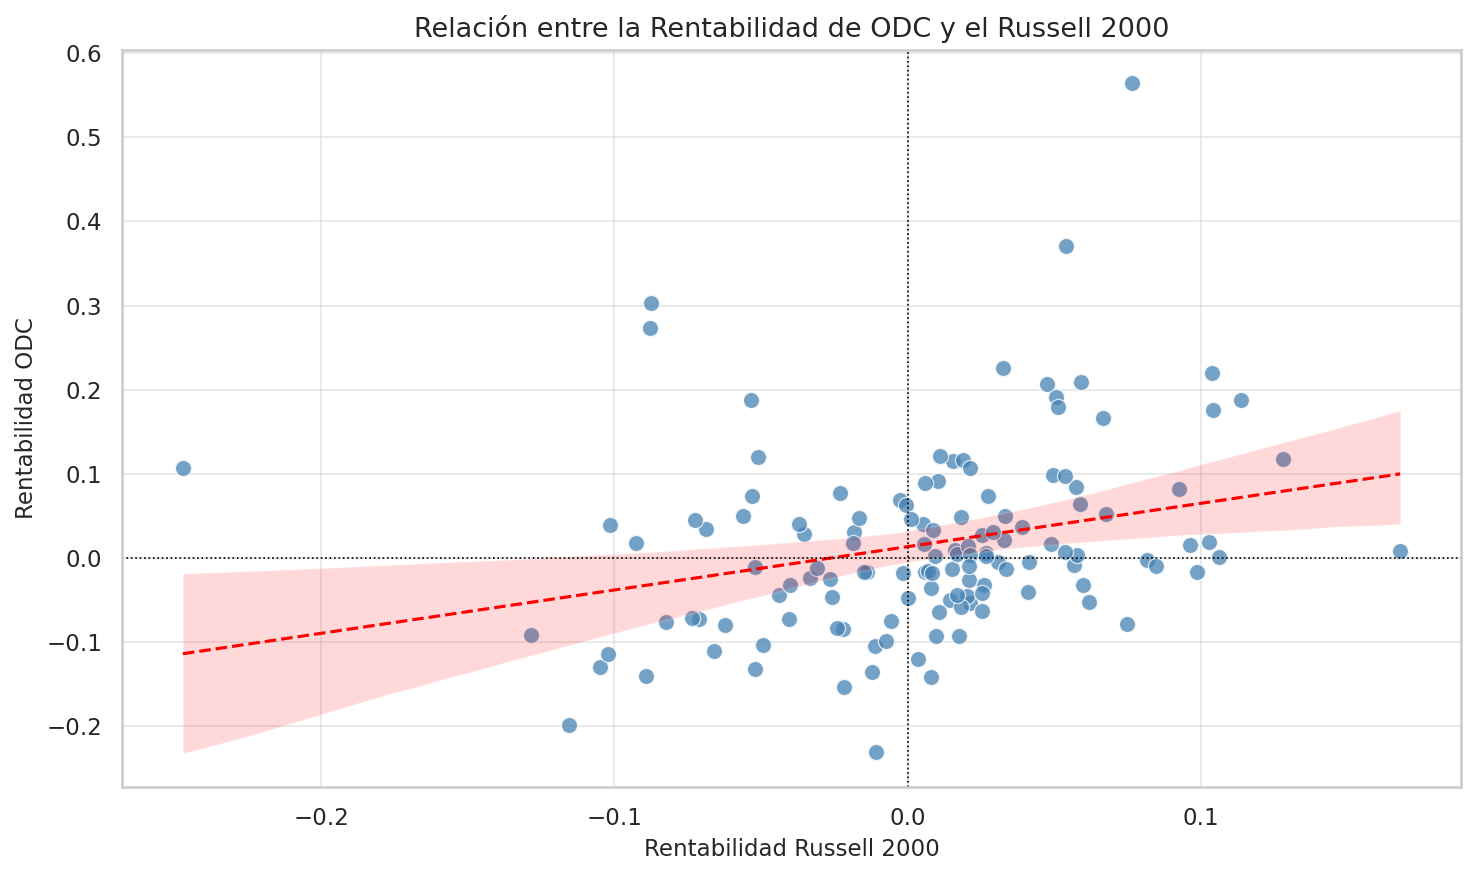

In [6]:
# 3.3 Scatterplot: Relación entre la rentabilidad mensual de ODC y R2000

fig, ax = plt.subplots()
sns.scatterplot(data=df, x='Rentabilidad_R2000', y='Rentabilidad_ODC',
                color='steelblue', edgecolor='white', s=60, alpha=0.75, ax=ax)
sns.regplot(data=df, x='Rentabilidad_R2000', y='Rentabilidad_ODC',
            scatter=False, color='red',
            line_kws={'linewidth': 1.5, 'linestyle': '--'}, ci=95, ax=ax)
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.axvline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_title('Relación entre la Rentabilidad de ODC y el Russell 2000', fontsize=13)
ax.set_xlabel('Rentabilidad Russell 2000', fontsize=11)
ax.set_ylabel('Rentabilidad ODC', fontsize=11)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('ODC_R2000_recta.png', dpi=150)
plt.show()

La nube de puntos muestra una relación positiva entre las rentabilidades de ODC y el índice Russell 2000, evidenciando un comportamiento pro-cíclico respecto al mercado de referencia. La pendiente de la recta de regresión ajustada constituye una estimación visual preliminar del coeficiente beta del activo. La elevada dispersión de los retornos alrededor de la recta sugiere un componente significativo de riesgo idiosincrático, lo que indica que factores específicos de ODC tienen un peso determinante en su rendimiento más allá de la evolución macroeconómica capturada por el índice.

## 4. Estimación del Modelo CAPM

El Modelo de Valoración de Activos de Capital (CAPM) establece una relación lineal entre el rendimiento esperado de un activo y su exposición al riesgo sistemático de mercado. La especificación econométrica estimada por Mínimos Cuadrados Ordinarios (MCO) es:

$$R_{i,t} - R_{f,t} = \alpha + \beta \left(R_{m,t} - R_{f,t}\right) + \varepsilon_t$$

donde $\alpha$ es el alfa de Jensen (rentabilidad anormal), $\beta$ recoge el riesgo sistemático, y $\varepsilon_t$ es el término de perturbación estocástica.

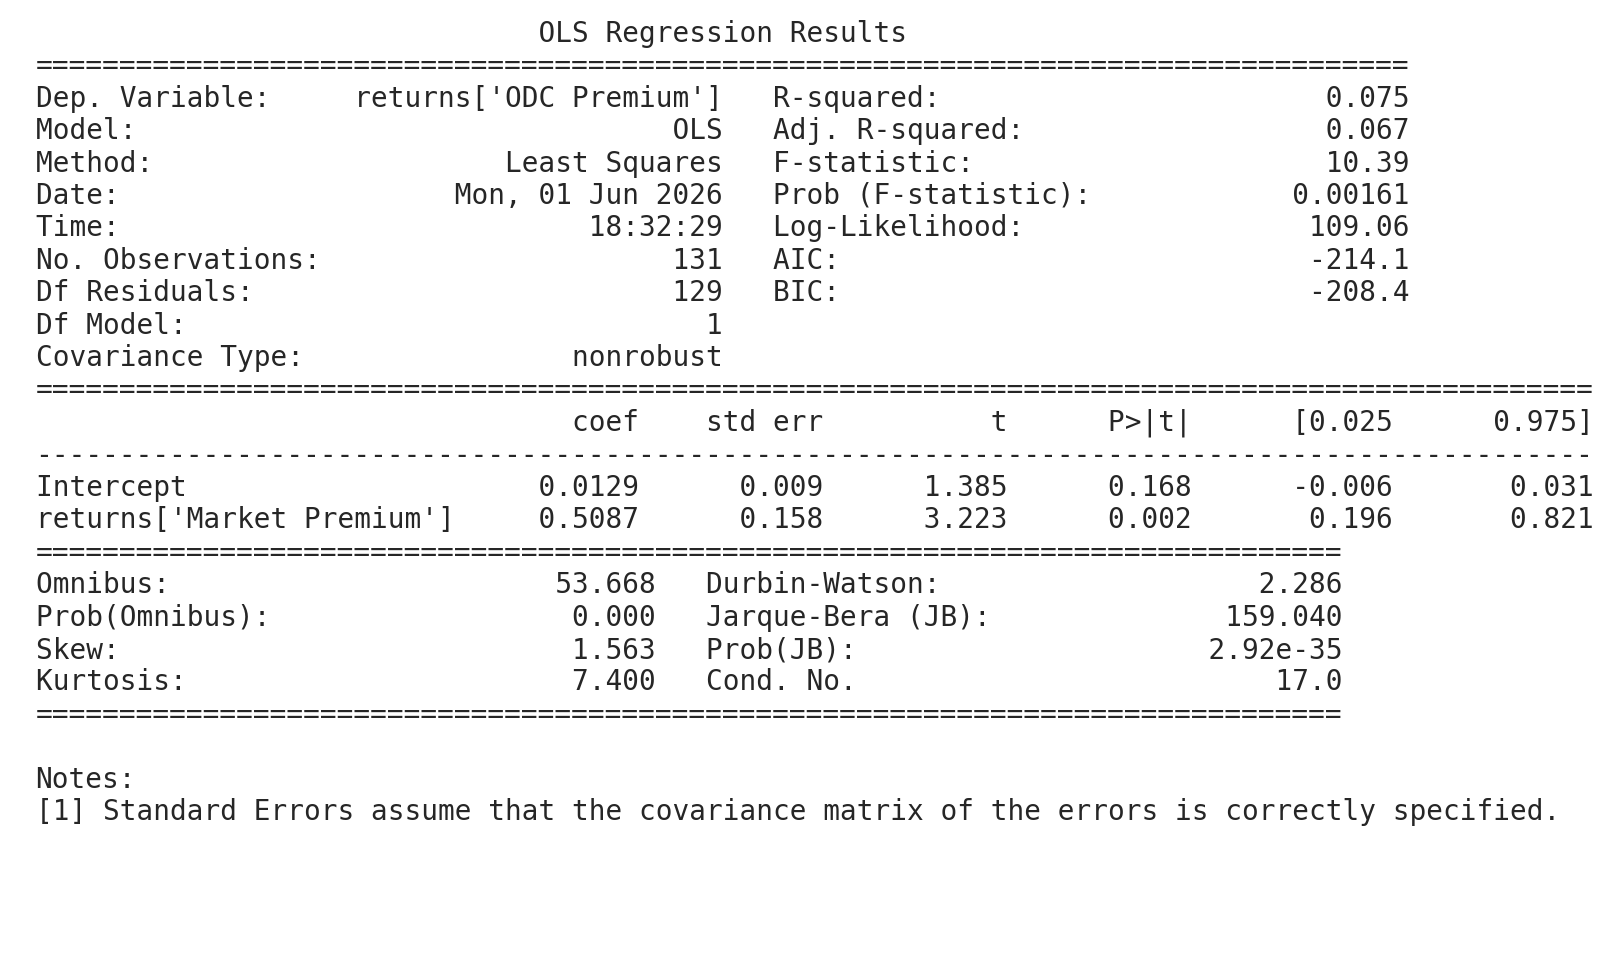

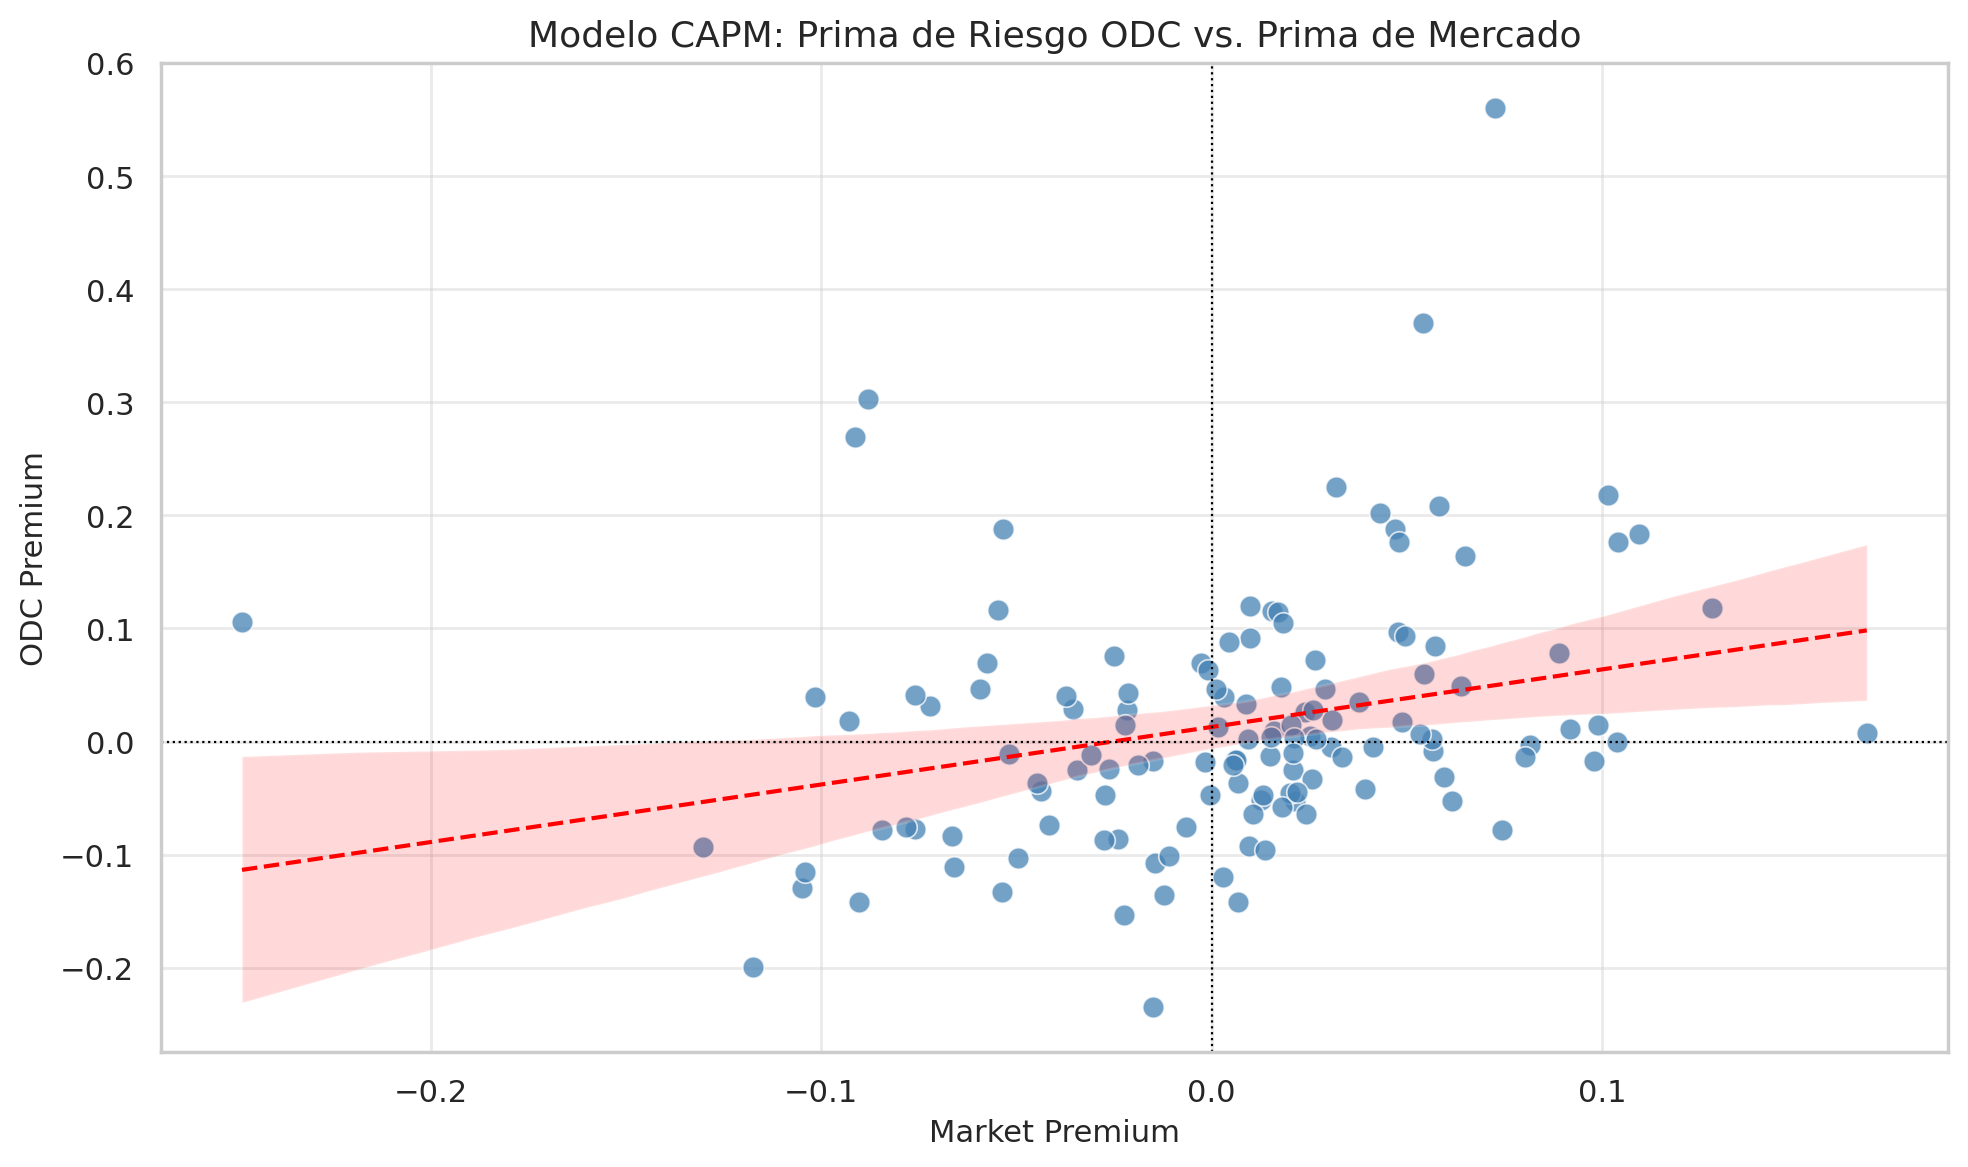

In [7]:
# 4. Estimación inicial del modelo CAPM

modelo_capm = sm.OLS.from_formula(
    "returns['ODC Premium'] ~ returns['Market Premium']",
    data=returns
).fit()

# Guardar output como imagen
plt.rc('figure', figsize=(9, 5), dpi=200)
plt.text(0.01, 0.99, modelo_capm.summary(), {'fontsize': 10}, fontproperties='monospace')
plt.axis('off')
plt.tight_layout()
plt.savefig('regresion_capm_01.png')
plt.show()

# Dispersión de primas con recta de regresión
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=returns, x='Market Premium', y='ODC Premium',
                color='steelblue', edgecolor='white', s=60, alpha=0.75, ax=ax)
sns.regplot(data=returns, x='Market Premium', y='ODC Premium',
            scatter=False, color='red',
            line_kws={'linewidth': 1.5, 'linestyle': '--'}, ci=95, ax=ax)
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.axvline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_title('Modelo CAPM: Prima de Riesgo ODC vs. Prima de Mercado', fontsize=13)
ax.set_xlabel('Market Premium', fontsize=11)
ax.set_ylabel('ODC Premium', fontsize=11)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('CAPM_Primas_ODC_Market.png', dpi=150)
plt.show()

**Interpretación de los resultados del CAPM inicial.**

El coeficiente $\beta$ estimado ($\beta = 0{,}5087$, $p = 0{,}002$) es estadísticamente significativo e inferior a la unidad, lo que clasifica a ODC como un activo de perfil defensivo: ante un incremento del 1\% en la prima del mercado, la prima de rentabilidad de ODC aumenta en promedio 0,51 puntos porcentuales. El alfa de Jensen estimado ($\alpha = 0{,}0129$, $p = 0{,}168$) no resulta estadísticamente significativo, lo que es coherente con la hipótesis de mercados eficientes en su forma semifuerte. El bajo poder explicativo del modelo ($R^2 = 0{,}075$) pone de manifiesto que el comportamiento del activo está dominado por su riesgo idiosincrático, lo que motiva el análisis de residuos que se desarrolla a continuación.

## 5. Diagnóstico y Análisis de Residuos

La validez de las inferencias estadísticas derivadas del modelo MCO depende del cumplimiento de los supuestos clásicos de Gauss-Markov sobre el término de error. A continuación se evalúan empíricamente los tres supuestos relevantes: normalidad, homocedasticidad y ausencia de autocorrelación.

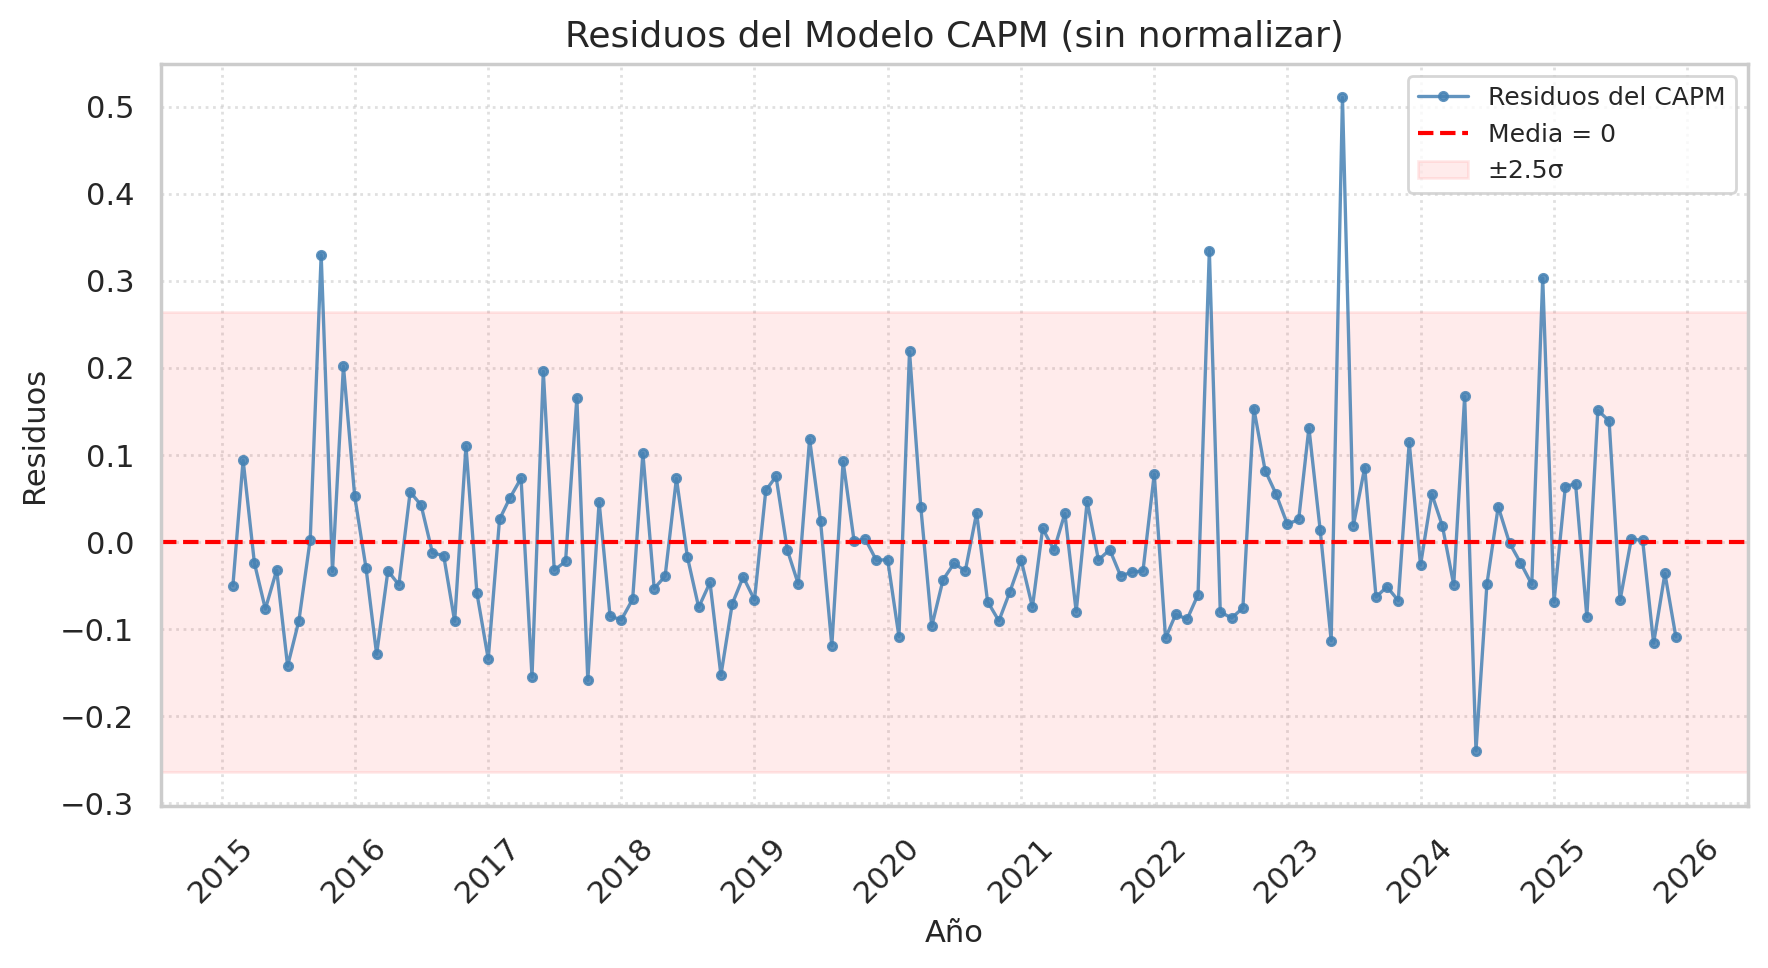

In [8]:
# 5. Extracción y visualización de residuos sin normalizar

returns['residuos'] = modelo_capm.resid.values

# Conversión explícita del índice para compatibilidad con matplotlib
fechas = returns.index.to_numpy()

fig, ax = plt.subplots()
ax.plot(fechas, returns['residuos'].values,
        marker='o', markersize=3, linestyle='-', linewidth=1.2,
        color='steelblue', alpha=0.85, label='Residuos del CAPM')
ax.axhline(0, color='red', linewidth=1.5, linestyle='--', label='Media = 0')
std_resid = returns['residuos'].std()
ax.axhspan(-2.5*std_resid, 2.5*std_resid, color='red', alpha=0.08, label='±2.5σ')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
ax.set_title('Residuos del Modelo CAPM (sin normalizar)', fontsize=13)
ax.set_xlabel('Año', fontsize=11); ax.set_ylabel('Residuos', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('residuos_sin_normalizar.png', dpi=150)
plt.show()

### 5.1 Normalidad

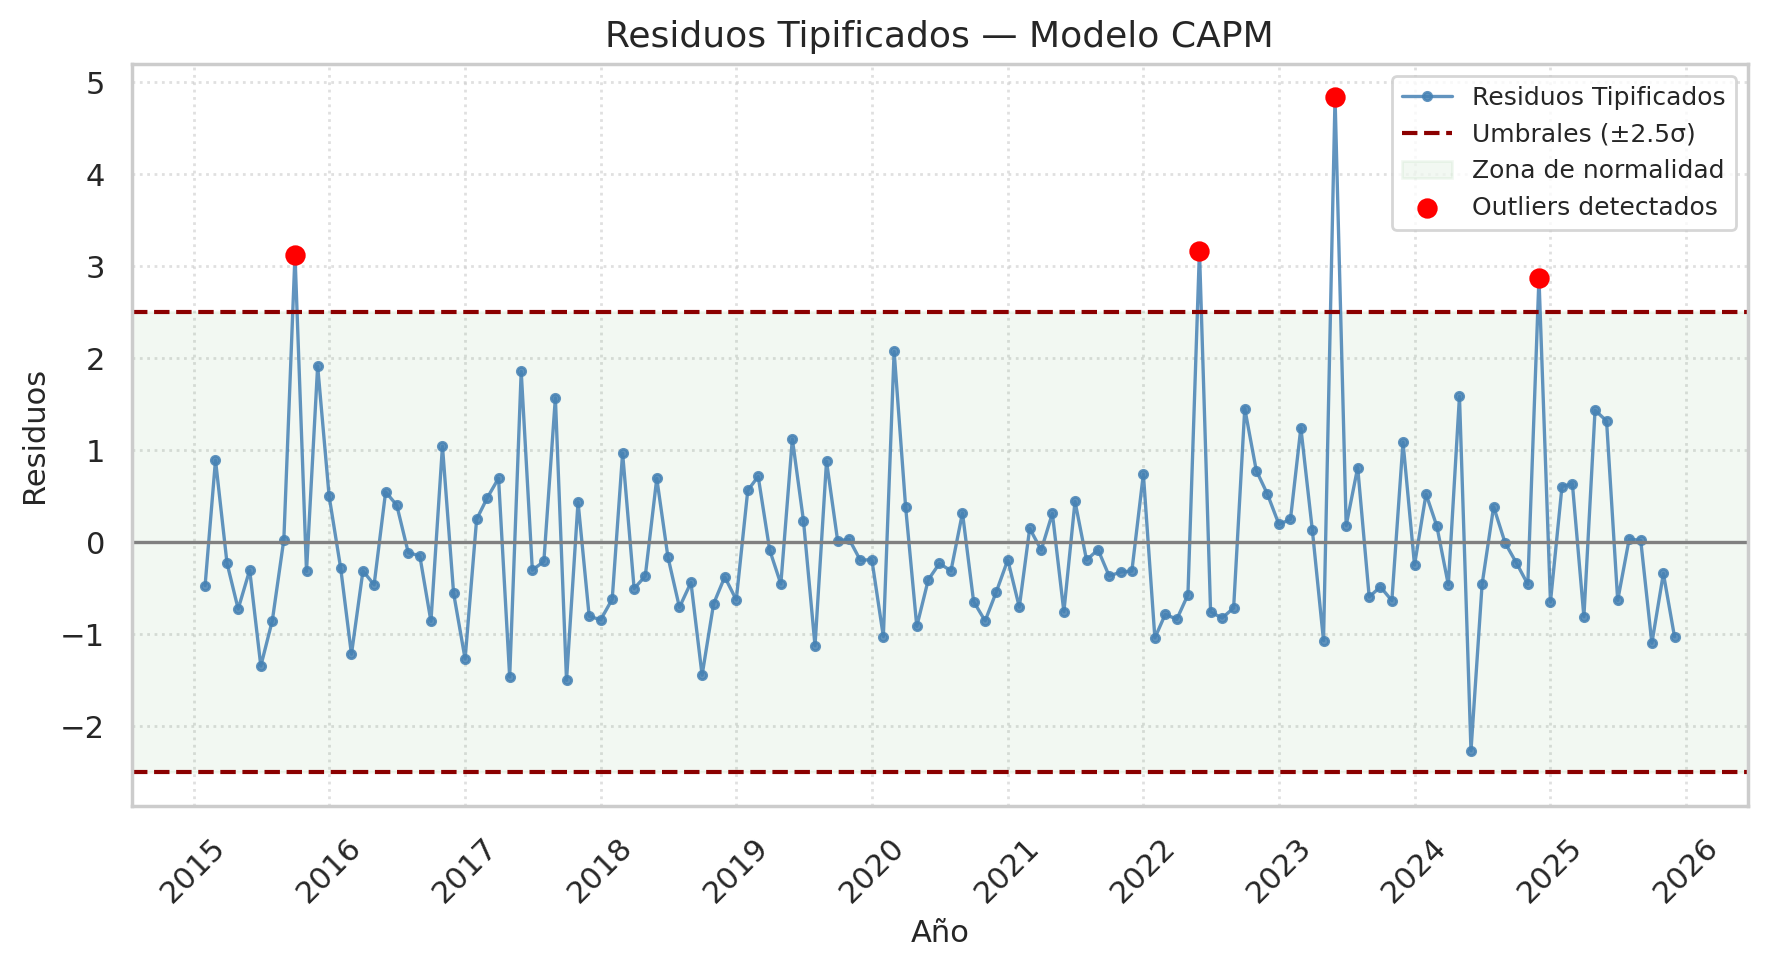

Outliers detectados (superan ±2.5σ):
Date
2015-10-01    3.122877
2022-06-01    3.169527
2023-06-01    4.834349
2024-12-01    2.870334
Name: residuos_normalizados, dtype: float64


In [9]:
# 5.1.1 Residuos tipificados e identificación de outliers

if not isinstance(returns.index, pd.DatetimeIndex):
    returns.index = pd.to_datetime(returns.index)

residuos_normalizados = (returns['residuos'] - returns['residuos'].mean()) / returns['residuos'].std()
returns['residuos_normalizados'] = residuos_normalizados
fechas = returns.index.to_numpy()

fig, ax = plt.subplots()
ax.plot(fechas, returns['residuos_normalizados'].values,
        marker='o', markersize=3, linestyle='-', linewidth=1.2,
        color='steelblue', alpha=0.85, label='Residuos Tipificados')
ax.axhline(0,    color='gray',    linewidth=1.2, linestyle='-')
ax.axhline( 2.5, color='darkred', linewidth=1.5, linestyle='--', label='Umbrales (±2.5σ)')
ax.axhline(-2.5, color='darkred', linewidth=1.5, linestyle='--')
ax.axhspan(-2.5, 2.5, color='green', alpha=0.05, label='Zona de normalidad')

outliers = returns[abs(returns['residuos_normalizados']) > 2.5]
if not outliers.empty:
    ax.scatter(outliers.index, outliers['residuos_normalizados'],
               color='red', s=40, zorder=5, label='Outliers detectados')

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
ax.set_title('Residuos Tipificados — Modelo CAPM', fontsize=13)
ax.set_xlabel('Año', fontsize=11); ax.set_ylabel('Residuos', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', fontsize=9, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('Residuos_tipificados.png', dpi=150)
plt.show()

print("Outliers detectados (superan ±2.5σ):")
print(outliers['residuos_normalizados'])

In [10]:
# 5.1.2 Test de Jarque-Bera



alpha_sig = 0.05
jb_stat, jb_p, jb_skew, jb_kurt = sm.stats.jarque_bera(residuos_normalizados)

print("=" * 45)
print("TEST DE JARQUE-BERA — Normalidad de Residuos")
print("=" * 45)
print(f"  H₀: sesgo = 0 y curtosis = 3 (normalidad)")
print(f"  Estadístico JB : {jb_stat:.4f}")
print(f"  p-valor        : {jb_p:.4f}")
print(f"  Sesgo          : {jb_skew:.4f}   (referencia = 0)")
print(f"  Curtosis       : {jb_kurt:.4f}  (referencia = 3)")
print("-" * 45)
print(f"  Conclusión: H₀ {'RECHAZADA' if jb_p < alpha_sig else 'NO rechazada'} (p {'<' if jb_p < alpha_sig else '>'} {alpha_sig})")

TEST DE JARQUE-BERA — Normalidad de Residuos
  H₀: sesgo = 0 y curtosis = 3 (normalidad)
  Estadístico JB : 159.0397
  p-valor        : 0.0000
  Sesgo          : 1.5634   (referencia = 0)
  Curtosis       : 7.4000  (referencia = 3)
---------------------------------------------
  Conclusión: H₀ RECHAZADA (p < 0.05)


El estadístico de Jarque-Bera alcanza un valor de 159,04 con un $p$-valor de 0,0000, lo que implica el rechazo categórico de la hipótesis nula de normalidad. La presencia de leptocurtosis y asimetría positiva en los residuos es coherente con la existencia de observaciones atípicas de carácter idiosincrásico, cuya corrección mediante variables de intervención se aborda en la sección 6.

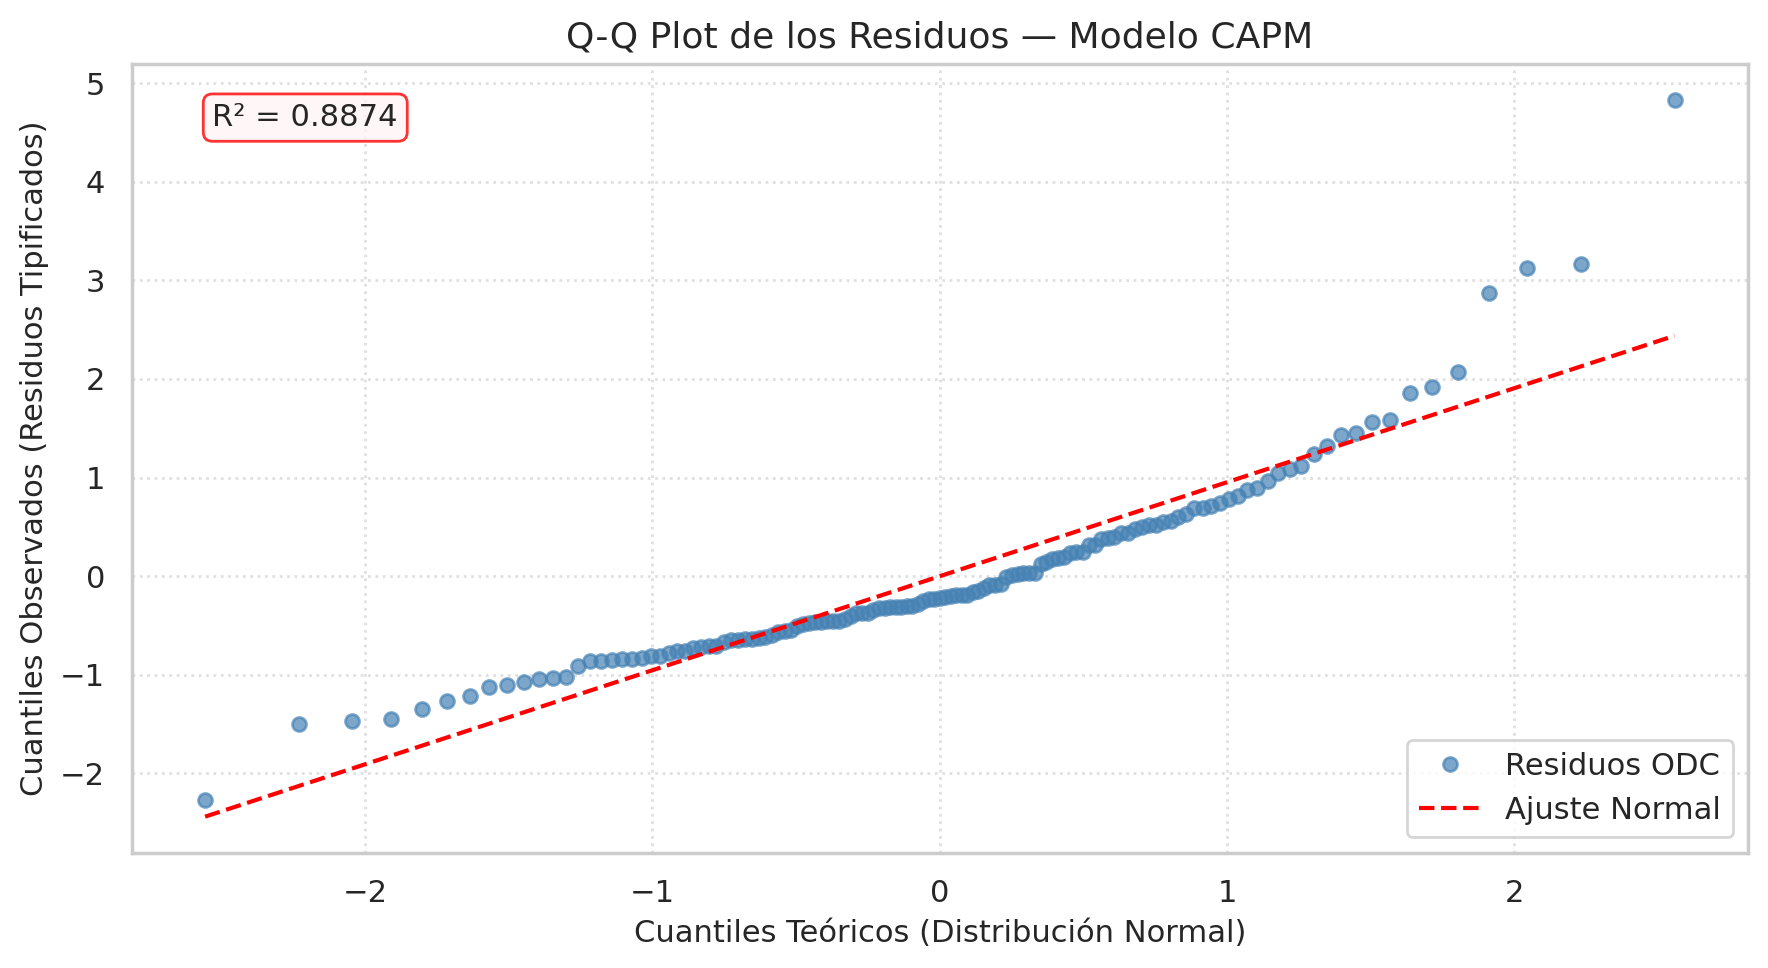

In [11]:
# 5.1.3 Gráfico Q-Q Plot de los residuos

fig, ax = plt.subplots()
(osm, osr), (slope, intercept, r) = stats.probplot(residuos_normalizados, dist="norm", fit=True)
ax.plot(osm, osr, marker='o', linestyle='none', color='steelblue', alpha=0.7, markersize=5, label='Residuos ODC')
ax.plot(osm, slope * osm + intercept, color='red', linewidth=1.5, linestyle='--', label='Ajuste Normal')
props = dict(boxstyle='round', facecolor='#FFF5F5', alpha=0.8, edgecolor='red')
ax.text(0.05, 0.95, f'R² = {r**2:.4f}', transform=ax.transAxes,
        fontsize=11, verticalalignment='top', bbox=props)
ax.set_title('Q-Q Plot de los Residuos — Modelo CAPM', fontsize=13)
ax.set_xlabel('Cuantiles Teóricos (Distribución Normal)', fontsize=11)
ax.set_ylabel('Cuantiles Observados (Residuos Tipificados)', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6); ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('residuos_qqplot.png', dpi=150)
plt.show()

### 5.2 Homocedasticidad

In [12]:
# 5.2.1 Test de Breusch-Pagan

bp_test = het_breuschpagan(returns['residuos'], modelo_capm.model.exog)
print("Test de Breusch-Pagan para Heterocedasticidad:")
print(f"  Estadístico LM : {bp_test[0]:.4f}")
print(f"  p-valor        : {bp_test[1]:.4f}")
print(f"  Conclusión     : Homocedasticidad {'rechazada' if bp_test[1] < 0.05 else 'no rechazada'} (α = 0.05)")

Test de Breusch-Pagan para Heterocedasticidad:
  Estadístico LM : 0.1142
  p-valor        : 0.7354
  Conclusión     : Homocedasticidad no rechazada (α = 0.05)


**Elección de 12 rezagos en el test de Ljung-Box:**
La convención para datos mensuales es min(20, T/5). Lo que para T=131 equivaldría a 20 lags.
Se adoptan 12 (un ciclo anual completo) porque la estructura de autocorrelación en rentabilidades financieras mensuales se manifiesta típicamente en los primeros lags(Campbell, Lo & MacKinlay, 1997). 
Ampliar a 20 reduce la potencia del test sin aportar estructura económica adicional. 
**Se ha verificado que la extensión a 20 rezagos no altera la conclusión general.**

In [13]:
# 5.2.2 Test de White

white_test = het_white(modelo_capm.resid, modelo_capm.model.exog)
labels = ['Estadístico LM', 'p-valor LM', 'Estadístico F', 'p-valor F']
print("Test de White para Heterocedasticidad:")
for lbl, val in zip(labels, white_test):
    print(f"  {lbl:<18}: {val:.4f}")
print(f"  Conclusión     : Homocedasticidad {'rechazada' if white_test[1] < 0.05 else 'no rechazada'} (α = 0.05)")

Test de White para Heterocedasticidad:
  Estadístico LM    : 3.4845
  p-valor LM        : 0.1751
  Estadístico F     : 1.7489
  p-valor F         : 0.1781
  Conclusión     : Homocedasticidad no rechazada (α = 0.05)


In [ ]:
# 5.2.3 Gráfico de residuos vs. valores ajustados

fig, ax = plt.subplots()
fitted   = modelo_capm.fittedvalues
residuos = modelo_capm.resid
sns.scatterplot(x=fitted, y=residuos, color='steelblue', edgecolor='white',
                s=50, alpha=0.75, ax=ax, label='Residuos observados')
sns.regplot(x=fitted, y=residuos, scatter=False, lowess=True, color='green',
            line_kws={'linewidth': 2, 'linestyle': '--'}, ax=ax, label='Tendencia LOWESS')
ax.axhline(0, color='red', linewidth=1.5, linestyle='-', label='Media teórica')
ax.set_title('Residuos vs. Valores Ajustados — Detección de Heterocedasticidad', fontsize=13)
ax.set_xlabel('Valores Ajustados', fontsize=11); ax.set_ylabel('Residuos', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6); ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('residuos_valoresajustados.png', dpi=150)
plt.show()

Tanto el test de Breusch-Pagan ($p = 0{,}7354$) como el test de White confirman la no existencia de heterocedasticidad en los residuos del modelo. La distribución de los residuos frente a los valores ajustados es homogénea y sin patrones sistemáticos. En consecuencia, el supuesto de varianza constante se considera satisfecho y la estimación HAC de Newey-West, incluida en la sección 6.1, se presenta únicamente a título ilustrativo de robustez.

### 5.3 Autocorrelación

In [ ]:
# 5.3.1 Test de Ljung-Box (12 rezagos — convención para datos mensuales)

residuos = modelo_capm.resid
lb_test  = acorr_ljungbox(residuos, lags=12)

print("Test de Ljung-Box para Autocorrelación:")
print(f"{'Lag':<6} | {'Estadístico Q':<16} | {'p-valor'}")
print("-" * 38)
for i, row in lb_test.iterrows():
    print(f"{i:<6} | {row['lb_stat']:<16.4f} | {row['lb_pvalue']:.4f}")
print("-" * 38)
autocorr = any(p < 0.05 for p in lb_test['lb_pvalue'])
print(f"\nConclusión (α = 0.05): {'Autocorrelación DETECTADA' if autocorr else 'NO se detecta autocorrelación significativa'}")
print(f"Nota: lag 1 presenta p = {lb_test['lb_pvalue'].iloc[0]:.4f} (marginalmente no significativo al 5%).")


In [ ]:
# 5.3.2 Gráficos ACF y PACF

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

plot_acf(residuos, lags=20, alpha=0.05, zero=False, ax=ax1,
         color='steelblue', vlines_kwargs={'colors': 'steelblue', 'linewidth': 2},
         title='Función de Autocorrelación (ACF)')
ax1.set_xlabel('Rezagos', fontsize=11); ax1.set_ylabel('Autocorrelación', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)

plot_pacf(residuos, lags=20, alpha=0.05, zero=False, ax=ax2,
          color='darkorange', vlines_kwargs={'colors': 'darkorange', 'linewidth': 2},
          title='Función de Autocorrelación Parcial (PACF)')
ax2.set_xlabel('Rezagos', fontsize=11); ax2.set_ylabel('Autocorrelación Parcial', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Análisis de Autocorrelación en los Residuos del CAPM', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('Residuos_ACF_PACF.png', bbox_inches='tight', dpi=150)
plt.show()

Los correlogramas ACF y PACF muestran que la gran mayoría de los coeficientes de rezago se sitúan dentro de las bandas de confianza al 95%, lo que indica visualmente la ausencia de correlación serial significativa. El test de Ljung-Box confirma este resultado de forma formal: ningún $p$-valor supera el umbral del 5%. El lag 1 presenta un $p$-valor de 0,0864, marginalmente no significativo, cuyo valor se documenta como hallazgo empírico sin que invalide la conclusión general de no autocorrelación.

## 6. Corrección Econométrica: Estimación Robusta y Variables de Intervención

### 6.1 Estimación de Newey-West (análisis de robustez) --> *Ilustrativo*

La corrección de Newey-West (HAC) ajusta la matriz de varianzas y covarianzas para hacerla robusta frente a la presencia simultánea de heterocedasticidad y autocorrelación. Dado que los tests de las secciones 5.2 y 5.3 no detectan ninguno de estos problemas en el modelo inicial, esta estimación se presenta exclusivamente a título ilustrativo, con el fin de demostrar que los coeficientes son robustos a posibles desviaciones no captadas por los tests formales.

In [ ]:
# 6.1 Estimación robusta Newey-West — análisis de robustez ilustrativo
# Los tests de Breusch-Pagan (p=0.735) y Ljung-Box (todos p>0.05) no justifican
# la corrección HAC como modelo principal. Se incluye para demostrar robustez.

modelo_capm_nw = sm.OLS.from_formula(
    "returns['ODC Premium'] ~ returns['Market Premium']",
    data=returns
).fit(cov_type='HAC', cov_kwds={'maxlags': 1})

plt.rc('figure', figsize=(9, 5), dpi=200)
plt.text(0.01, 0.05, modelo_capm_nw.summary(), {'fontsize': 10}, fontproperties='monospace')
plt.axis('off')
plt.tight_layout()
plt.savefig('regresion_capm_nw.png')
plt.show()

print(modelo_capm_nw.summary())

### 6.2 Variables de Intervención (Dummies de Outliers)

Al analizar un modelo de regresión se detectan con frecuencia observaciones atípicas cuyos residuos superan el umbral convencional de ±2,5 desviaciones estándar. Cuando su aparición responde a un evento concreto, conocido y de carácter temporal, la alternativa metodológicamente más adecuada a su eliminación es la inclusión de variables dummy de intervención puntual. Este enfoque preserva la integridad de la serie temporal y permite cuantificar el impacto diferencial de cada evento sin distorsionar la estimación de los parámetros estructurales (Box y Tiao, 1975).

La especificación econométrica del modelo corregido es:

$$R_{i,t} - R_{f,t} = \alpha + \beta(R_{m,t} - R_{f,t}) + \delta_1 D1_t + \delta_2 D2_t + \delta_3 D3_t + \delta_4 D4_t + \varepsilon_t$$

donde cada $D_{k,t}$ adopta el valor 1 en el mes del evento $k$ y 0 en el resto del período.

In [ ]:
# 6.2.1 Creación de las cuatro dummies de intervención

# D1 — Oct-2015: Beneficios FY2015 +109% interanual
returns['outlier_201510'] = (returns.index == '2015-10-01').astype(int)

# D2 — Jun-2022: Deterioro operativo + cargo por deterioro de goodwill (Q3 FY2022)
returns['outlier_202206'] = (returns.index == '2022-06-01').astype(int)

# D3 — Jun-2023: Resultados históricos récord Q3 FY2023 (+4.83σ)
returns['outlier_202306'] = (returns.index == '2023-06-01').astype(int)

# D4 — Dic-2024: Márgenes históricos + incremento de dividendo (Q1 FY2025)
returns['outlier_202412'] = (returns.index == '2024-12-01').astype(int)

# Verificación: cada dummy debe sumar exactamente 1
print("Verificación de dummies:")
for col in ['outlier_201510', 'outlier_202206', 'outlier_202306', 'outlier_202412']:
    n = returns[col].sum()
    print(f"  {col}: {n} obs  {'Yes' if n == 1 else 'Error'}")

**Justificación económica de cada intervención.**

**D1 (Octubre de 2015):** ODC reportó en su ejercicio fiscal 2015 un beneficio neto de aproximadamente 18 millones de dólares, lo que representó un incremento interanual del 109% frente a los 8,6 millones del FY2014. Este resultado extraordinario superó ampliamente las expectativas del mercado y generó un fuerte movimiento alcista en la cotización durante ese mes.

**D2 (Junio de 2022):** El 7 de junio de 2022 se produjo un shock positivo, tras la publicación de los resultados del tercer trimestre fiscal. Las ventas netas alcanzaron 85,8 millones de dólares (+12% interanual) causadas por subidas de precios en todos los segmentos de negocio. Aunque el resultado neto del trimestre registró una pérdida de 2,1 millones de dólares (a causa de un cargo no recurrente y no monetario por deterioro de fondo de comercio de 5,6 millones de dólares), el mercado valoró de forma positiva el crecimiento sostenido en ventas

**D3 (Junio de 2023):** Entre el 7 y el 8 de junio de 2023, ODC anunció los mejores resultados trimestrales de su historia: crecimiento de ventas del 23% interanual, margen bruto del 26,1% y un flujo de caja operativo acumulado de nueve meses que pasó de 5,5 a 36,8 millones de dólares. Este outlier alcista, el más extremo de la muestra (+4,83σ), fue consecuencia directa de la expansión de márgenes documentada en el capítulo 2.

**D4 (Diciembre de 2024):** El 9 de diciembre de 2024, ODC presentó resultados récord del primer trimestre fiscal con un beneficio neto de 16,4 millones de dólares (+52% interanual) y un margen bruto del 32%. El movimiento alcista se vio reforzado el 11 de diciembre por el anuncio de un incremento del dividendo trimestral.

In [ ]:
# 6.2.2 Estimación del modelo CAPM corregido con las 4 dummies

formula_outliers = (
    "Q('ODC Premium') ~ Q('Market Premium') + "
    "outlier_201510 + outlier_202206 + outlier_202306 + outlier_202412"
)

modelo_outliers = sm.OLS.from_formula(formula_outliers, data=returns).fit(
    cov_type='HAC', cov_kwds={'maxlags': 1}
)

# Guardar output
plt.rc('figure', figsize=(9, 5), dpi=200)
plt.text(0.01, 0.05, modelo_outliers.summary(), {'fontsize': 10}, fontproperties='monospace')
plt.axis('off')
plt.tight_layout()
plt.savefig('regresion_capm_nw_outlier.png')
plt.show()

print(modelo_outliers.summary())

In [ ]:
# 1. Definición de la fórmula de tu modelo definitivo (CAPM + 4 dummies)
formula_outliers = (
    "Q('ODC Premium') ~ Q('Market Premium') + "
    "outlier_201510 + outlier_202206 + outlier_202306 + outlier_202412"
)

# 2. Estimación original (maxlags = 1)
modelo_hac_1 = sm.OLS.from_formula(formula_outliers, data=returns).fit(
    cov_type='HAC', cov_kwds={'maxlags': 1}
)

# 3. Estimación de robustez (maxlags = 3, cubre autocorrelaciones hasta 9-12 meses)
modelo_hac_3 = sm.OLS.from_formula(formula_outliers, data=returns).fit(
    cov_type='HAC', cov_kwds={'maxlags': 3}
)

# 4. Generación de tabla comparativa
tabla_comparativa = summary_col(
    [modelo_hac_1, modelo_hac_3],
    model_names=['HAC (maxlags=1)', 'HAC (maxlags=3)'],
    stars=True,
    info_dict={
        'R² Ajustado': lambda x: f"{x.rsquared_adj:.4f}",
        'F-statistic': lambda x: f"{x.fvalue:.2f}"
    }
)

print("--- COMPARACIÓN EMPÍRICA DE ROBUSTEZ DE ERRORES ESTÁNDAR ---")
print(tabla_comparativa)

# 5. Extracción de estadísticos para la Beta del Mercado (tu conclusión clave)
beta_1 = modelo_hac_1.params["Q('Market Premium')"]
pval_1 = modelo_hac_1.pvalues["Q('Market Premium')"]
se_1 = modelo_hac_1.bse["Q('Market Premium')"]

beta_3 = modelo_hac_3.params["Q('Market Premium')"]
pval_3 = modelo_hac_3.pvalues["Q('Market Premium')"]
se_3 = modelo_hac_3.bse["Q('Market Premium')"]

print("\n--- IMPACTO SOBRE LA BETA DEL MERCADO ---")
print(f"HAC (1 rezago)  -> Beta: {beta_1:.4f} | Error Estándar: {se_1:.4f} | P-valor: {pval_1:.5f}")
print(f"HAC (3 rezagos) -> Beta: {beta_3:.4f} | Error Estándar: {se_3:.4f} | P-valor: {pval_3:.5f}")

# 6. Conclusión automática basada en significatividad (alfa = 0.05)
if pval_3 < 0.05:
    print("\n VERIFICACIÓN SUPERADA: La beta del mercado se mantiene estadísticamente significativa al 5%.")
    print("Empíricamente, corregir por autocorrelaciones de orden superior (3 rezagos) no cambia las conclusiones de la investigación.")
else:
    print("\n ALERTA: La beta del mercado pierde significatividad al 5% al ampliar el ancho de banda.")

In [ ]:
# 6.2.3 Test de Wald - Significatividad conjunta de las 4 dummies

restricciones_outliers = [
    'outlier_201510 = 0',
    'outlier_202206 = 0',
    'outlier_202306 = 0',
    'outlier_202412 = 0'
]

test_wald_outliers = modelo_outliers.wald_test(restricciones_outliers, use_f=False)
print("--- Test de Wald: Significatividad Conjunta de las 4 Dummies ---")
print(f"H₀: δ₁ = δ₂ = δ₃ = δ₄ = 0 (ninguna dummy es necesaria)")
print(test_wald_outliers)

El test de Wald conjunto rechaza la hipótesis nula de que las cuatro dummies son conjuntamente nulas ($\chi^2 \approx 3397{,}99$, $p \approx 0$), confirmando que su inclusión es estadísticamente necesaria. La inclusión de las variables de intervención eleva el $R^2$ de 0,075 a 0,452, aislando el efecto de los shocks idiosincrásicos sin distorsionar la estimación de los parámetros estructurales.

In [ ]:
# 6.2.4 Diagnóstico de residuos del modelo corregido

returns['residuos_outlier'] = modelo_outliers.resid.values

# Extraer arrays numpy para compatibilidad con la versión de matplotlib del entorno
residuos_arr = returns['residuos_outlier'].to_numpy()

# Histograma con curva normal teórica
fig, ax = plt.subplots()
ax.hist(residuos_arr, bins=20, density=True,
        color='steelblue', edgecolor='white', linewidth=0.5, alpha=0.75,
        label='Residuos observados')

# KDE manual con scipy
kde_x = np.linspace(residuos_arr.min(), residuos_arr.max(), 300)
kde   = stats.gaussian_kde(residuos_arr)
ax.plot(kde_x, kde(kde_x), color='steelblue', linewidth=1.5, linestyle='-', label='KDE')

# Curva normal teórica
mu, sigma = residuos_arr.mean(), residuos_arr.std()
ax.plot(kde_x, stats.norm.pdf(kde_x, mu, sigma),
        color='red', linewidth=1.5, linestyle='--',
        label=f'Normal teórica N({mu:.3f}, {sigma:.3f}²)')

ax.set_title('Distribución de Residuos — Modelo CAPM Corregido', fontsize=13)
ax.set_xlabel('Residuos del Modelo Corregido', fontsize=11)
ax.set_ylabel('Densidad', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('Histograma_Residuos_Dummy_ODC.png', dpi=150)
plt.show()

# Q-Q Plot
fig, ax = plt.subplots()
(osm, osr), (slope, intercept, pearson_r) = stats.probplot(residuos_arr, dist="norm", fit=True)
ax.plot(osm, osr, marker='o', linestyle='none', color='steelblue',
        alpha=0.7, markersize=5, label='Residuos ODC')
ax.plot(osm, slope * osm + intercept, color='red', linewidth=1.5,
        linestyle='--', label=f'Normal: μ={intercept:.3f}, σ={slope:.3f}')
props = dict(boxstyle='round', facecolor='#FFF5F5', alpha=0.8, edgecolor='red')
ax.text(0.05, 0.95, f'R² = {pearson_r**2:.4f}', transform=ax.transAxes,
        fontsize=11, verticalalignment='top', bbox=props)
ax.set_title(f'Q-Q Plot de los Residuos — Modelo Corregido (n={len(returns)})', fontsize=13)
ax.set_xlabel('Cuantiles Teóricos', fontsize=11)
ax.set_ylabel('Cuantiles Observados', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('residuosdummy_qqplot.png', dpi=150)
plt.show()

# Test de Jarque-Bera sobre residuos corregidos
jb_stat, p_value, skew, kurtosis = sm.stats.jarque_bera(residuos_arr)
print("=" * 45)
print("TEST DE JARQUE-BERA — Residuos Modelo Corregido")
print("=" * 45)
print(f"  Estadístico JB : {jb_stat:.4f}")
print(f"  p-valor        : {p_value:.4f}")
print(f"  Sesgo          : {skew:.4f}   (referencia = 0)")
print(f"  Curtosis       : {kurtosis:.4f}  (referencia = 3)")
print("-" * 45)
print(f"  Conclusión: H₀ {'RECHAZADA' if p_value < 0.05 else 'NO rechazada'} "
      f"(p {'<' if p_value < 0.05 else '>'} 0.05)")
print("  Nota: rechazo marginal al exacto umbral del 5%. Sesgo y curtosis")
print("  próximos a los valores de referencia; el TCL valida los contrastes.")

In [ ]:
# 6.2.5 Diagnóstico completo del modelo CAPM corregido (modelo_outliers)

resid_corr = modelo_outliers.resid
exog_corr = modelo_outliers.model.exog

# Breusch-Pagan
bp = het_breuschpagan(resid_corr, exog_corr)
print("=== Breusch-Pagan (Modelo corregido) ===")
print(f"  LM = {bp[0]:.4f},  p-valor = {bp[1]:.4f}")

# White
wh = het_white(resid_corr, exog_corr)
print(f"\n=== White (Modelo corregido) ===")
print(f"  LM = {wh[0]:.4f},  p-valor = {wh[1]:.4f}")
print(f"  F  = {wh[2]:.4f},  p-valor = {wh[3]:.4f}")

# Ljung-Box (12 rezagos)
lb = acorr_ljungbox(resid_corr, lags=12, return_df=True)
print(f"\n=== Ljung-Box (Modelo corregido) ===")
print(lb.to_string())
print(f"\n  Autocorrelación detectada: {'Sí' if (lb['lb_pvalue'] < 0.05).any() else 'No'}")


## 7. Contraste de Estabilidad Paramétrica

Un cambio estructural implica una alteración significativa y duradera en los parámetros del modelo, es decir, en la constante ($\alpha$), en la pendiente ($\beta$) o en ambos. Su presencia comprometería la validez de la especificación única estimada para todo el período. Dado que el evento de mayor magnitud de la muestra corresponde a junio de 2023 (D3, +4,83σ), se contrasta si a partir de esa fecha la relación entre ODC y el Russell 2000 se modificó estructuralmente.

In [ ]:
# 7.1 Creación de la dummy escalón D_jun2023

returns['D_jun2023'] = (returns.index >= pd.Timestamp('2023-06-01')).astype(int)

print(f"Obs. pre-junio 2023  (D_jun2023=0): {(returns['D_jun2023'] == 0).sum()}")
print(f"Obs. post-junio 2023 (D_jun2023=1): {(returns['D_jun2023'] == 1).sum()}")
print(f"Primer mes con D_jun2023=1: {returns[returns['D_jun2023'] == 1].index.min().date()}")

In [ ]:
# 7.2 Estimación de los tres casos de cambio estructural

T    = len(returns)
lags = int(4 * (T / 100) ** (2/9))
hac  = dict(cov_type='HAC', cov_kwds={'maxlags': lags})

# Caso 1: Cambio solo en la constante (shift en α)
caso1 = sm.OLS.from_formula(
    "Q('ODC Premium') ~ Q('Market Premium') + D_jun2023",
    data=returns).fit(**hac)

# Caso 2: Cambio solo en la pendiente (shift en β)
caso2 = sm.OLS.from_formula(
    "Q('ODC Premium') ~ Q('Market Premium') + D_jun2023:Q('Market Premium')",
    data=returns).fit(**hac)

# Caso 3: Cambio conjunto en constante y pendiente
caso3 = sm.OLS.from_formula(
    "Q('ODC Premium') ~ Q('Market Premium') + D_jun2023 + D_jun2023:Q('Market Premium')",
    data=returns).fit(**hac)

# Tabla comparativa
tabla = summary_col(
    [caso1, caso2, caso3],
    model_names=['Caso 1 (α)', 'Caso 2 (β)', 'Caso 3 (α+β)'],
    stars=True,
    info_dict={'R² Adj': lambda x: f"{x.rsquared_adj:.4f}",
               'AIC':    lambda x: f"{x.aic:.2f}"}
)
print(tabla)

In [ ]:
# 7.3 Test de Wald conjunto — H₀: no hay cambio estructural en junio 2023

restricciones_estructural = [
    "D_jun2023 = 0",
    "D_jun2023:Q('Market Premium') = 0"
]

test_wald_estructural = caso3.wald_test(restricciones_estructural, use_f=False)
print("--- Test de Wald: Cambio Estructural Conjunto ---")
print(f"H₀: D_jun2023 = 0  ∩  D_jun2023·β = 0  (sin cambio estructural)")
print(test_wald_estructural)

In [ ]:
# 7.4 Diagnóstico comparativo de residuos: Caso 3 vs. Modelo con Outliers

returns['residuos_caso3'] = caso3.resid.values
returns['residuos_final']  = modelo_outliers.resid.values

# Q-Q Plot comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, titulo in [
    (ax1, 'residuos_caso3', 'Caso 3 — Cambio Estructural'),
    (ax2, 'residuos_final', 'Modelo Definitivo — Con Outliers'),
]:
    (osm, osr), (slope, intercept, pearson_r) = stats.probplot(returns[col], dist="norm", fit=True)
    ax.plot(osm, osr, marker='o', linestyle='none', color='steelblue', alpha=0.7, markersize=5, label='Residuos ODC')
    ax.plot(osm, slope * osm + intercept, color='red', linewidth=1.5, linestyle='--',
            label=f'Normal: μ={intercept:.3f}, σ={slope:.3f}')
    props = dict(boxstyle='round', facecolor='#FFF5F5', alpha=0.8, edgecolor='red')
    ax.text(0.05, 0.95, f'R² = {pearson_r**2:.4f}', transform=ax.transAxes,
            fontsize=10, verticalalignment='top', bbox=props)
    ax.set_title(f'Q-Q Plot — {titulo}', fontsize=12)
    ax.set_xlabel('Cuantiles Teóricos', fontsize=11)
    ax.set_ylabel('Cuantiles Observados', fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.6); ax.legend(loc='lower right', fontsize=10)

plt.suptitle('Q-Q Plot Comparativo de Residuos', fontsize=13)
plt.tight_layout()
plt.savefig('residuos_qqplot_comparativo.png', dpi=150)
plt.show()

In [ ]:
# 7.5 Comparativa de Distribución de Residuos: Modelo con Outliers vs. Cambio Estructural (Caso 3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

for ax, col, titulo in [
    (ax1, 'residuos_final',  'Modelo con Outliers'),
    (ax2, 'residuos_caso3',  'Modelo Cambio Estructural (Caso 3)'),
]:
    datos = returns[col].dropna().values  # <-- convertir a numpy array
    
    ax.hist(datos, bins=20, density=True, color='steelblue',
            edgecolor='white', alpha=0.75)
    
    # Curva normal teórica
    mu, sigma = datos.mean(), datos.std()
    x = np.linspace(datos.min(), datos.max(), 200)
    ax.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2, label='Normal teórica')
    kde = gaussian_kde(datos)
    ax.plot(x, kde(x), '--', color='darkblue', lw=1.5, label='KDE empírica')
    
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Residuos')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparativa_residuos_outliers_vs_caso3.png',
            dpi=150, bbox_inches='tight')
plt.show()


El test de Wald conjunto no rechaza la hipótesis nula de ausencia de cambio estructural ($\chi^2 = 1{,}566$, $p = 0{,}457$), lo que confirma que los parámetros del modelo se han mantenido estables durante todo el período analizado, incluso tras el evento de mayor magnitud de la muestra. El gráfico Q-Q comparativo muestra que los residuos del modelo con dummies de outliers presentan colas más próximas a la línea teórica que los del Caso 3, lo que evidencia que la especificación con intervenciones puntuales es superior a la del cambio estructural para este activo.

In [ ]:
# 7.6 Betas recursivas expansivas — Modelo CAPM definitivo

min_obs = 36  # Ventana mínima: 3 años de datos mensuales

y = returns["ODC Premium"]
X = returns[["Market Premium",
             "outlier_201510", "outlier_202206",
             "outlier_202306", "outlier_202412"]].copy()
X = sm.add_constant(X)

alphas, betas = [], []
alpha_ci_lo, alpha_ci_hi = [], []
beta_ci_lo,  beta_ci_hi  = [], []
fechas = []

for t in range(min_obs, len(X) + 1):
    y_t = y.iloc[:t]
    X_t = X.iloc[:t]

    # Excluir dummies que sean todo ceros en la submuestra
    cols = ["const", "Market Premium"]
    for d in ["outlier_201510", "outlier_202206",
              "outlier_202306", "outlier_202412"]:
        if X_t[d].sum() > 0:
            cols.append(d)

    modelo_t = sm.OLS(y_t, X_t[cols]).fit(
        cov_type="HAC", cov_kwds={"maxlags": 1}
    )

    alphas.append(modelo_t.params["const"])
    betas.append(modelo_t.params["Market Premium"])

    ci = modelo_t.conf_int(alpha=0.05)
    alpha_ci_lo.append(ci.loc["const", 0])
    alpha_ci_hi.append(ci.loc["const", 1])
    beta_ci_lo.append(ci.loc["Market Premium", 0])
    beta_ci_hi.append(ci.loc["Market Premium", 1])
    fechas.append(returns.index[t - 1])

# Figura 1: Beta recursiva 
fig, ax = plt.subplots(figsize=(12, 5), dpi=150)
ax.plot(fechas, betas, color="#1F4E79", lw=1.8,
        label=r"$\hat{\beta}_t$ recursivo")
ax.fill_between(fechas, beta_ci_lo, beta_ci_hi,
                alpha=0.2, color="#2E75B6", label="IC 95 %")
ax.axhline(0.5306, color="#CC0000", ls="--", lw=1,
           label=r"$\hat{\beta}$ estático = 0,5306")
ax.axhline(1.0, color="gray", ls=":", lw=0.8,
           label=r"$\beta = 1$ (mercado)")
ax.set_xlabel("Fecha")
ax.set_ylabel(r"$\hat{\beta}_t$")
ax.set_title("Beta recursiva - Modelo CAPM definitivo (IC 95 %)",
             fontsize=13, fontweight="bold")
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("beta_recursiva_capm_definitivo.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Figura 2: Alfa recursivo 
fig, ax = plt.subplots(figsize=(12, 5), dpi=150)
ax.plot(fechas, alphas, color="#1F4E79", lw=1.8,
        label=r"$\hat{\alpha}_t$ recursivo")
ax.fill_between(fechas, alpha_ci_lo, alpha_ci_hi,
                alpha=0.2, color="#2E75B6", label="IC 95 %")
ax.axhline(0.0, color="gray", ls="--", lw=1,
           label=r"$\alpha = 0$")
ax.set_xlabel("Fecha")
ax.set_ylabel(r"$\hat{\alpha}_t$")
ax.set_title("Alfa recursivo - Modelo CAPM definitivo (IC 95 %)",
             fontsize=13, fontweight="bold")
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("alfa_recursivo_capm_definitivo.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Resumen numérico ──
print(f"Beta recursiva final:  {betas[-1]:.4f}")
print(f"Alpha recursivo final: {alphas[-1]:.4f}")
print(f"Beta estática (ref.):  0.5306")
print(f"Convergencia beta:     {'✅ Sí' if abs(betas[-1] - 0.5306) < 0.05 else '⚠️ Revisar'}")

## 8. Modelo de Tres Factores de Fama y French

El modelo de tres factores de Fama y French (1993) extiende el CAPM incorporando dos factores adicionales que documentan rentabilidades sistemáticas no capturadas por el factor de mercado: la prima de tamaño (SMB, *Small Minus Big*) y la prima de valor (HML, *High Minus Low*). La especificación econométrica es:

$$R_{i,t} - R_{f,t} = \alpha + \beta_m(R_{m,t} - R_{f,t}) + \beta_s \cdot SMB_t + \beta_v \cdot HML_t + \varepsilon_t$$

Dado que ODC es una empresa de pequeña capitalización incluida en el Russell 2000, se anticipa una carga positiva en el factor SMB. Las cuatro variables de intervención puntual identificadas en la sección 6.2 se incorporan al modelo para aislar el efecto de los shocks idiosincrásicos.

In [ ]:
# 8.0 Verificación de disponibilidad de factores en returns

print("Columnas disponibles en returns:")
print(returns.columns.tolist())
print(f"\nPeríodo: {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"Observaciones: {len(returns)}")

In [ ]:
# 8.1 Estimación del modelo Fama-French completo (los tres factores)

formula_ff3 = (
    "Q('ODC Premium') ~ Q('Market Premium') + SMB + HML + "
    "outlier_201510 + outlier_202206 + outlier_202306 + outlier_202412"
)

modelo_ff3 = sm.OLS.from_formula(formula_ff3, data=returns).fit(
    cov_type='HAC', cov_kwds={'maxlags': 1}
)

# Guardar output
plt.rc('figure', figsize=(9, 6), dpi=200)
plt.text(0.01, 0.05, modelo_ff3.summary(), {'fontsize': 9}, fontproperties='monospace')
plt.axis('off')
plt.tight_layout()
plt.savefig('regresion_ff3_completo.png')
plt.show()

print(modelo_ff3.summary())

In [ ]:
# 8.2 Evaluación de la significatividad de SMB y HML

key_mkt = "Q('Market Premium')"

print("Significatividad de los factores (modelo FF3 completo):")
print(f"  Market Premium : p = {modelo_ff3.pvalues[key_mkt]:.4f}")
print(f"  SMB            : p = {modelo_ff3.pvalues['SMB']:.4f}")
print(f"  HML            : p = {modelo_ff3.pvalues['HML']:.4f}")
print()
print("Decisión metodológica:")
print("  Si p(SMB) > 0.05 y p(HML) > 0.05 → ambos factores se excluyen.")
print("  El modelo definitivo coincide con el CAPM corregido de la sección 6.2.")

In [ ]:
# 8.3 Modelo Fama-French definitivo
# Dado que SMB (p=0.8113) y HML (p=0.6810) no son significativos al 5%,
# ambos factores se excluyen. El modelo definitivo es el CAPM corregido.

formula_ff3_def = (
    "Q('ODC Premium') ~ Q('Market Premium') + "
    "outlier_201510 + outlier_202206 + outlier_202306 + outlier_202412"
)

modelo_ff3_def = sm.OLS.from_formula(formula_ff3_def, data=returns).fit(
    cov_type='HAC', cov_kwds={'maxlags': 1}
)

# Comparación de ajuste
print("Comparación de R² ajustado:")
print(f"  FF3 completo (SMB + HML incluidos) : {modelo_ff3.rsquared_adj:.4f}")
print(f"  Modelo definitivo (sin SMB ni HML) : {modelo_ff3_def.rsquared_adj:.4f}")
print()
print("Conclusión: la inclusión de SMB y HML no mejora el ajuste del modelo.")
print("El CAPM corregido de la sección 6.2 constituye la especificación definitiva.")
print()
print(modelo_ff3_def.summary())

In [ ]:
# 8.4 Diagnóstico de residuos del modelo Fama-French definitivo

residuos_ff3 = modelo_ff3_def.resid

# Test de Jarque-Bera
jb_stat, jb_p, jb_skew, jb_kurt = sm.stats.jarque_bera(residuos_ff3)
print("=" * 50)
print("TEST DE JARQUE-BERA — Residuos Modelo FF3 Definitivo")
print("=" * 50)
print(f"  Estadístico JB : {jb_stat:.4f}")
print(f"  p-valor        : {jb_p:.4f}")
print(f"  Sesgo          : {jb_skew:.4f}")
print(f"  Curtosis       : {jb_kurt:.4f}")
print(f"  Conclusión     : H₀ {'RECHAZADA' if jb_p < 0.05 else 'NO rechazada'} (α = 0.05)\n")

# Test de Ljung-Box
lb_ff3 = acorr_ljungbox(residuos_ff3, lags=12)
print("TEST DE LJUNG-BOX — Autocorrelación (12 rezagos)")
print(f"{'Lag':<6} | {'Q':<12} | {'p-valor'}")
print("-" * 32)
for i, row in lb_ff3.iterrows():
    print(f"{i:<6} | {row['lb_stat']:<12.4f} | {row['lb_pvalue']:.4f}")
autocorr = any(p < 0.05 for p in lb_ff3['lb_pvalue'])
print(f"\nConclusión: {'Autocorrelación DETECTADA' if autocorr else 'NO se detecta autocorrelación'}\n")

# Test de Breusch-Pagan
bp_stat, bp_p, _, _ = het_breuschpagan(residuos_ff3, modelo_ff3_def.model.exog)
print("TEST DE BREUSCH-PAGAN — Homocedasticidad")
print(f"  Estadístico LM : {bp_stat:.4f}")
print(f"  p-valor        : {bp_p:.4f}")
print(f"  Conclusión     : {'Heterocedasticidad DETECTADA' if bp_p < 0.05 else 'Homocedasticidad NO rechazada'}")

In [ ]:
# 8.5 Q-Q Plot — Residuos del modelo FF3 definitivo

fig, ax = plt.subplots()
(osm, osr), (slope, intercept, pearson_r) = stats.probplot(residuos_ff3, dist="norm", fit=True)
ax.plot(osm, osr, marker='o', linestyle='none', color='steelblue', alpha=0.7, markersize=5, label='Residuos ODC (FF3)')
ax.plot(osm, slope * osm + intercept, color='red', linewidth=1.5, linestyle='--', label='Ajuste Normal')
props = dict(boxstyle='round', facecolor='#FFF5F5', alpha=0.8, edgecolor='red')
ax.text(0.05, 0.95, f'R² = {pearson_r**2:.4f}', transform=ax.transAxes,
        fontsize=11, verticalalignment='top', bbox=props)
ax.set_title('Q-Q Plot — Residuos del Modelo Fama-French Definitivo', fontsize=13)
ax.set_xlabel('Cuantiles Teóricos (Distribución Normal)', fontsize=11)
ax.set_ylabel('Cuantiles Observados (Residuos)', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6); ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('FF3_residuos_qqplot.png', dpi=150)
plt.show()

In [ ]:
# 8.6 Contrastes de hipótesis sobre el modelo FF3 definitivo
# (siguiendo la estructura del notebook del tutor: TFG_06)

# H₀: α = 0 — ausencia de rentabilidad anormal
print("=" * 50)
print("CONTRASTE H₀: α = 0  (ausencia de rentabilidad anormal)")
print("=" * 50)
test_alpha = modelo_ff3_def.t_test('Intercept = 0')
print(test_alpha)

# H₀: β_m = 1 — igual riesgo sistemático que el mercado
print("\n" + "=" * 50)
print("CONTRASTE H₀: β_m = 1  (mismo riesgo que el mercado)")
print("=" * 50)
test_beta = modelo_ff3_def.t_test("Q('Market Premium') = 1")
print(test_beta)

# H₀ conjunta: α = 0 ∩ β_m = 1
print("\n" + "=" * 50)
print("CONTRASTE CONJUNTO H₀: α = 0  ∩  β_m = 1")
print("=" * 50)
restricciones = "Intercept = 0, Q('Market Premium') = 1"
test_conjunto = modelo_ff3_def.f_test(restricciones)
print(test_conjunto)

**Síntesis de resultados del modelo Fama-French.**

La estimación del modelo de tres factores revela que ni el factor SMB ($p = 0{,}8113$) ni el factor HML ($p = 0{,}6810$) resultan estadísticamente significativos al nivel del 5%. En consecuencia, ambos factores se excluyen del modelo definitivo, que coincide con el CAPM corregido estimado en la sección 6.2. Este resultado implica que, una vez controlados los cuatro eventos idiosincrásicos identificados, la variabilidad de la prima de rentabilidad de ODC queda explicada exclusivamente por su exposición al riesgo sistemático de mercado.

La ausencia de carga significativa en el factor SMB resulta, no obstante, contraintuitiva dado el perfil small-cap de la empresa, y puede atribuirse a que el uso del Russell 2000 como índice de referencia ya incorpora implícitamente el sesgo de tamaño, reduciendo la varianza marginal explicable por SMB en la regresión. Los contrastes de hipótesis confirman la no significatividad del alfa ($\alpha \approx 0$) y el rechazo de la hipótesis de igual riesgo sistemático que el mercado ($\beta_m \neq 1$), en línea con los resultados del capítulo 5.